In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()

True

In [13]:
model=ChatGoogleGenerativeAI(model="gemini-3.6-flash")

In [19]:
class POEM(TypedDict):
    title: str
    outline: str
    content: str

In [ ]:
def create_outline(state: POEM)->POEM:
    title = state["title"]
    prompt_template = PromptTemplate.from_template("Create an outline for a poem titled '{title}':")
    prompt = prompt_template.format(title=title)
    output_text = model.invoke(prompt).content 
    state["outline"] = output_text
    return state

In [23]:
def create_content(state: POEM)->POEM:
    content = state["outline"]
    prompt_template = PromptTemplate.from_template("create a poem based on this outline: {question}")
    prompt = prompt_template.format(question=content)
    output_text = model.invoke(prompt).content 
    state["content"] = output_text
    return state

In [24]:
graph=StateGraph(POEM)

graph.add_node("outline",create_outline)
graph.add_node("content",create_content)

graph.add_edge(START,"outline")
graph.add_edge("outline","content")
graph.add_edge("content",END)

workflow=graph.compile()

In [25]:
initial_state={"title": "create a poem about the ocean?"}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'create a poem about the ocean?', 'outline': [{'type': 'text', 'text': "Here is a structural outline for a poem titled **'create a poem about the ocean?'**. \n\nThis outline approaches the title as a meta-question: *How does a poet use limited human words to capture something as infinite, ancient, and alive as the ocean?*\n\n---\n\n### **Poem Outline: 'create a poem about the ocean?'**\n\n#### **Theme:** \nThe impossibility of capturing the vastness, power, and mystery of the sea using simple human language.\n\n#### **Tone:** \nReflective, awestruck, rhythmic, and slightly philosophical.\n\n#### **Form/Style:** \nFree verse with a subtle ebb-and-flow meter (short lines swelling into long lines, mimicking waves).\n\n---\n\n### **I. Stanza 1: The Blank Page and the Horizon (The Challenge)**\n* **Concept:** Addressing the title directly—sitting down to write, feeling dwarfed by the subject.\n* **Imagery:** The white blankness of paper contrasting with the endless blue of the hor

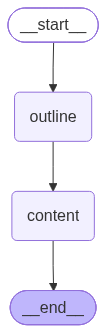

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())